In [85]:
import pandas as pd

import numpy as np
# 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
# 
from sklearn.model_selection import train_test_split
# 
from sklearn.ensemble import RandomForestClassifier
# 
from special_use_classes import OutlierHandling
import special_use_classes
import importlib
importlib.reload(special_use_classes)
# 
from sklearn.metrics import classification_report
# 
import matplotlib.pyplot as plt
import seaborn as sns
# 
# from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import  SMOTENC
outlier_handler = OutlierHandling()
# 
from joblib import dump
# 
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
pd.options.display.float_format = '{:,.2f}'.format
# 
# colors for plt
color_pastel = sns.color_palette('pastel')
color_deep = sns.color_palette('deep')
color_bright = sns.color_palette('bright')

In [86]:
# data is from kaggle : https://www.kaggle.com/datasets/mustafabayar/europe-sales-records
df = pd.read_csv(r'data\Europe Sales Records.csv')

In [87]:
df.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Europe,Czech Republic,Beverages,Offline,C,9/12/2011,478051030,9/29/2011,4778,47.45,31.79,"226,716.10","151,892.62","74,823.48"
1,Europe,Bosnia and Herzegovina,Clothes,Online,M,10/14/2013,919133651,11/4/2013,927,109.28,35.84,"101,302.56","33,223.68","68,078.88"
2,Europe,Austria,Cereal,Offline,C,8/13/2014,987410676,9/6/2014,5616,205.70,117.11,"1,155,211.20","657,689.76","497,521.44"
3,Europe,Bulgaria,Office Supplies,Online,L,10/31/2010,672330081,11/29/2010,6266,651.21,524.96,"4,080,481.86","3,289,399.36","791,082.50"
4,Europe,Estonia,Fruits,Online,L,9/28/2016,579463422,11/1/2016,4958,9.33,6.92,"46,258.14","34,309.36","11,948.78"


In [88]:
cols_to_drop = ['Region', 'Order ID']
for i in cols_to_drop:
    try:
        df.drop(columns={i}, inplace=True)
        
    except Exception as e:
        print(e)

In [89]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country         1330 non-null   object        
 1   Item Type       1330 non-null   object        
 2   Sales Channel   1330 non-null   object        
 3   Order Priority  1330 non-null   object        
 4   Order Date      1330 non-null   datetime64[ns]
 5   Ship Date       1330 non-null   datetime64[ns]
 6   Units Sold      1330 non-null   int64         
 7   Unit Price      1330 non-null   float64       
 8   Unit Cost       1330 non-null   float64       
 9   Total Revenue   1330 non-null   float64       
 10  Total Cost      1330 non-null   float64       
 11  Total Profit    1330 non-null   float64       
dtypes: datetime64[ns](2), float64(5), int64(1), object(4)
memory usage: 124.8+ KB


In [91]:
df.isna().sum()

Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

In [92]:
df.duplicated().sum()

0

Total Revenue: 102, Total Revenue: 0, Total: 102
________________

Total Cost: 143, Total Cost: 0, Total: 143
________________

Total Profit: 53, Total Profit: 0, Total: 53
________________

None


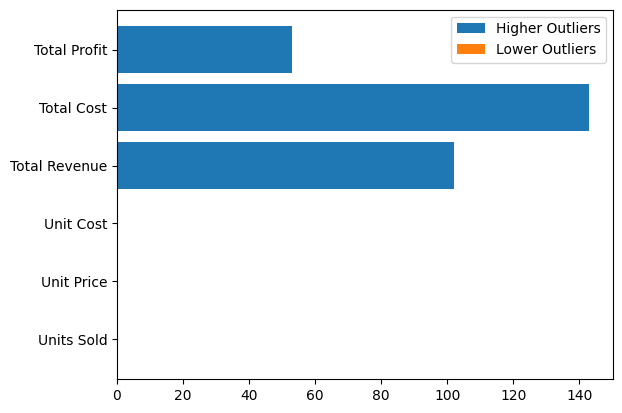

In [93]:
outlier_handler = OutlierHandling()


print(outlier_handler.count_outliers_df(df))
outlier_handler.plot(df)
plt.show()

In [94]:
for i in df.select_dtypes('object').columns.tolist():
    print(df[i].unique())
    print('\n\n')


['Czech Republic' 'Bosnia and Herzegovina' 'Austria' 'Bulgaria' 'Estonia'
 'Montenegro' 'Luxembourg' 'Switzerland' 'Finland' 'Belgium' 'San Marino'
 'Netherlands' 'Russia' 'Ukraine' 'Latvia' 'Serbia' 'Portugal' 'Poland'
 'Liechtenstein' 'United Kingdom' 'Slovenia' 'Malta' 'Cyprus' 'Monaco'
 'Norway' 'Armenia' 'Denmark' 'Kosovo' 'Hungary' 'Lithuania' 'Albania'
 'Moldova ' 'France' 'Spain' 'Sweden' 'Macedonia' 'Greece' 'Italy'
 'Germany' 'Andorra' 'Iceland' 'Croatia' 'Slovakia' 'Vatican City'
 'Belarus' 'Ireland' 'Romania' 'Georgia']



['Beverages' 'Clothes' 'Cereal' 'Office Supplies' 'Fruits' 'Vegetables'
 'Meat' 'Snacks' 'Baby Food' 'Household' 'Cosmetics' 'Personal Care']



['Offline' 'Online']



['C' 'M' 'L' 'H']





<p style='color: white; background-color:#5b1f18; padding:10px; border-radius:10px; text-align:center'>lets display the highest Profit in europe</p>

In [95]:
most_valued_country = df.nlargest(10,'Total Profit')[['Country','Total Profit']]
print(most_valued_country.head())


      Country  Total Profit
866   Andorra  1,700,448.60
1297   Norway  1,675,063.58
44    Albania  1,672,455.53
265   Germany  1,663,762.03
309   Albania  1,662,197.20


san marino tops the sales Profit 

In [96]:
high_Profit_df = df.nlargest(10, 'Total Profit')
high_Profit_df[['Country','Units Sold', 'Unit Price', 'Total Profit', 'Total Profit']]



,Country,Units Sold,Unit Price,Total Profit,Total Profit
866,Andorra,9780,437.20,"1,700,448.60","1,700,448.60"
1297,Norway,9634,437.20,"1,675,063.58","1,675,063.58"
44,Albania,9619,437.20,"1,672,455.53","1,672,455.53"
265,Germany,9569,437.20,"1,663,762.03","1,663,762.03"
309,Albania,9560,437.20,"1,662,197.20","1,662,197.20"
242,San Marino,9985,668.27,"1,654,814.05","1,654,814.05"
191,Hungary,9495,437.20,"1,650,895.65","1,650,895.65"
1134,Sweden,9492,437.20,"1,650,374.04","1,650,374.04"
405,Latvia,9382,437.20,"1,631,248.34","1,631,248.34"
390,Kosovo,9379,437.20,"1,630,726.73","1,630,726.73"


In [97]:
df['Total Profit'].max()

1700448.6

In [98]:
# df.groupby('')
df.columns

Index(['Country', 'Item Type', 'Sales Channel', 'Order Priority', 'Order Date',
       'Ship Date', 'Units Sold', 'Unit Price', 'Unit Cost', 'Total Revenue',
       'Total Cost', 'Total Profit'],
      dtype='object')

Country
Albania      524.96
Portugal     524.96
Luxembourg   524.96
Macedonia    524.96
Malta        524.96
Name: Unit Cost, dtype: float64


Text(0.5, 1.0, 'maximum unit price by country')

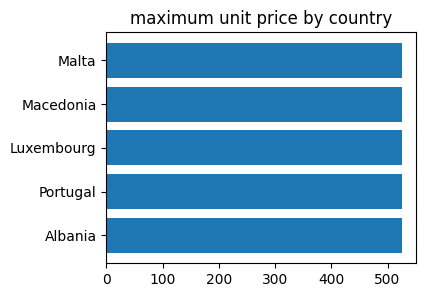

In [99]:
# نستعمل groupby دائما مع اداة aggregation
max_cost_by_country = df.groupby('Country')['Unit Cost'].max().sort_values(ascending=False).head(5)
print(max_cost_by_country)
plt.figure(figsize=(4,3))
plt.barh(max_cost_by_country.index, max_cost_by_country.values)
plt.title('maximum unit price by country')

Country
Albania     31.79
Portugal    31.79
Ukraine     31.79
Monaco      31.79
Croatia     31.79
Germany     31.79
Poland      31.79
Macedonia    6.92
Malta        6.92
Moldova      6.92
Name: Unit Cost, dtype: float64


Text(0.5, 1.0, 'minimum unit price by country')

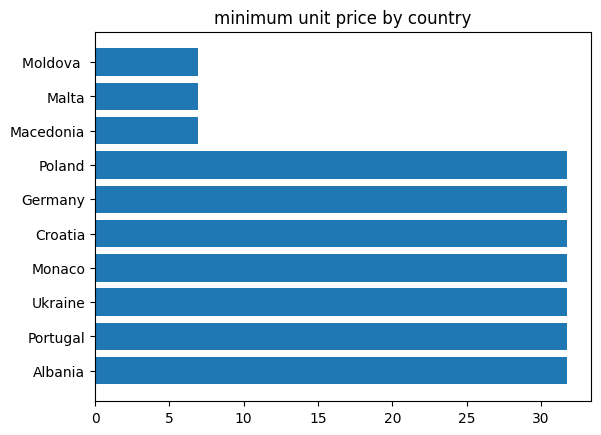

In [100]:
# نستعمل groupby دائما مع اداة aggregation
min_cost_by_country = df.groupby('Country')['Unit Cost'].min().sort_values(ascending=False).head(10)
print(min_cost_by_country)
plt.barh(min_cost_by_country.index, min_cost_by_country.values)
plt.title('minimum unit price by country')

In [101]:
# lets find out sales by month

# first lets make a month column extracting it from the order date

df['Order Date'].head()

df['Order Date'].dt.month_name().head() # -> now we have months name of the order date

# i can use that in aggregation (التجميع)
# df['month'] = 

df['month'] = df['Order Date'].dt.month_name()

# now another column for month ordering

df['month_num'] = df['Order Date'].dt.month

# df[['Order Date', 'month', 'month_num']]


    month_num      month  Total Profit
0           1    January 52,805,166.81
1           2   February 39,570,726.10
2           3      March 50,804,768.82
3           4      April 33,733,536.07
4           5        May 46,074,689.77
5           6       June 50,204,756.12
6           7       July 45,500,472.30
7           8     August 32,762,177.70
8           9  September 40,327,542.44
9          10    October 33,692,715.75
10         11   November 37,904,114.84
11         12   December 38,295,381.60


<BarContainer object of 12 artists>

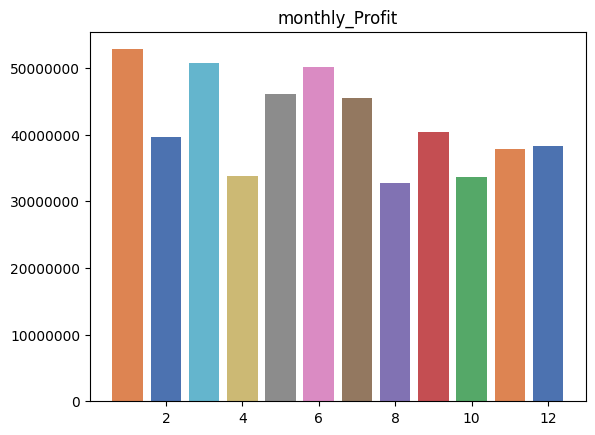

In [102]:
# now lets aggregate the month column with the total Profit

monthly_Profit = df.groupby(['month_num','month'])['Total Profit'].sum().reset_index()
print(monthly_Profit)
monthly_Profit['Total Profit'] = monthly_Profit['Total Profit'].round(0).astype(int)
monthly_Profit = monthly_Profit.sort_values('month_num', ascending=False)
plt.ticklabel_format(style='plain', axis='y')
plt.title('monthly_Profit')
plt.bar(monthly_Profit['month_num'], monthly_Profit['Total Profit'] , color=sns.color_palette('deep'))



Country
Monaco         4,797,048.77
Georgia        5,697,679.21
Netherlands    5,762,490.70
Vatican City   6,413,822.41
Moldova        6,902,456.08
Iceland        7,278,112.15
Croatia        7,388,447.57
Belgium        7,476,060.14
Finland        7,525,362.83
Estonia        7,828,593.56
Name: Total Profit, dtype: float64


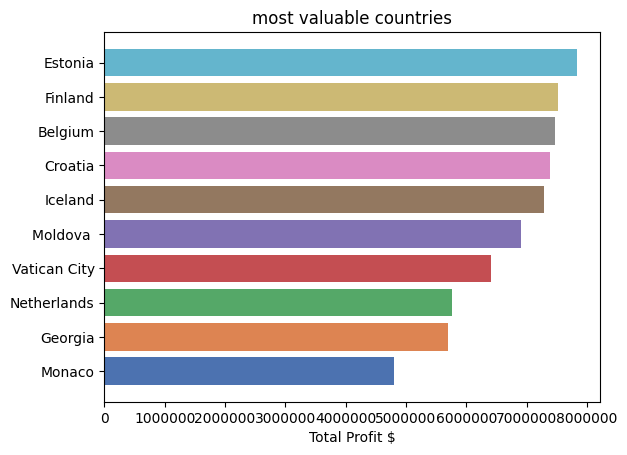

In [103]:
byCountry = df.groupby('Country')['Total Profit'].sum().sort_values().head(10)
print(byCountry)
plt.barh(byCountry.index, byCountry.values, color=color_deep)
plt.title('most valuable countries')
plt.xlabel('Total Profit $')
plt.ticklabel_format(style='plain', axis='x')

In [104]:
for i in df.columns.tolist():
    print(i)

Country
Item Type
Sales Channel
Order Priority
Order Date
Ship Date
Units Sold
Unit Price
Unit Cost
Total Revenue
Total Cost
Total Profit
month
month_num


       Country  Total Profit
0    Macedonia  3,082,933.47
1     Slovenia  3,033,912.82
2       Latvia  2,157,519.67
3      Ukraine  1,607,536.91
4  Switzerland  1,593,387.82


<BarContainer object of 10 artists>

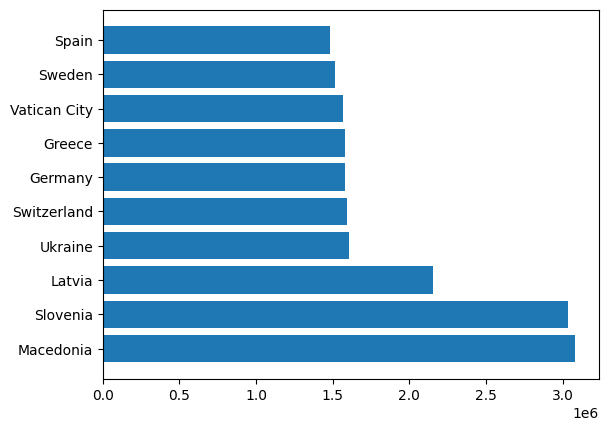

In [105]:
# df['Order Date'].dt.year.unique()

countries_revneue2017 = df[df['Order Date'].dt.year == 2017][['Country','Total Profit','Order Date']]
mv_countries_2017 = countries_revneue2017.groupby('Country')['Total Profit'].sum().sort_values(ascending=False).head(10).reset_index()
print(mv_countries_2017.head())

plt.barh(mv_countries_2017['Country'], mv_countries_2017['Total Profit'])
# plt.ticklabel_format(style='plain')
# countries_revneue2017.head()


          Country  Total Profit
0        Slovakia     10,539.18
1         Ireland    127,762.18
2        Moldova     147,049.24
3         Belgium    148,292.37
4      Montenegro    149,280.30
5          Poland    149,985.65
6  United Kingdom    152,935.96
7         Croatia    163,960.20
8         Hungary    172,367.64
9           Malta    177,149.14


<BarContainer object of 10 artists>

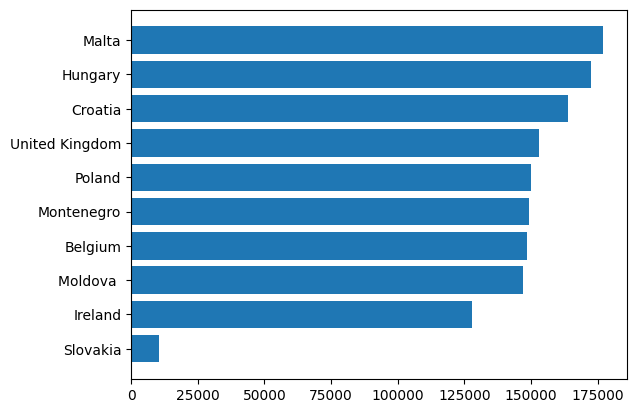

In [106]:
# now for least valueable countries
countries_revneue2017
lv_countries_2017 = countries_revneue2017.groupby('Country')['Total Profit'].sum().sort_values().head(10).reset_index()
print(lv_countries_2017)

plt.barh(lv_countries_2017['Country'], lv_countries_2017['Total Profit'])

In [107]:
# unitcost = 
countries_2017 = df[df['Order Date'].dt.year == 2017]
# i want to display most unit price and least total Profit countires
countries_2017['Unit Price']


13     421.89
14     668.27
20     668.27
22      47.45
34     152.58
        ...  
1246   154.06
1251   152.58
1256     9.33
1259   421.89
1285   154.06
Name: Unit Price, Length: 106, dtype: float64

          Item Type  Total Profit
0         Cosmetics 10,833,318.09
1   Office Supplies  6,632,543.75
2         Household  5,500,910.16
3            Snacks  4,088,851.56
4        Vegetables  2,953,663.31
5              Meat  2,500,898.40
6         Baby Food  2,204,971.72
7           Clothes  1,777,615.20
8         Beverages  1,267,739.64
9     Personal Care    648,828.46
10           Cereal    491,054.37
11           Fruits     99,296.82


<BarContainer object of 12 artists>

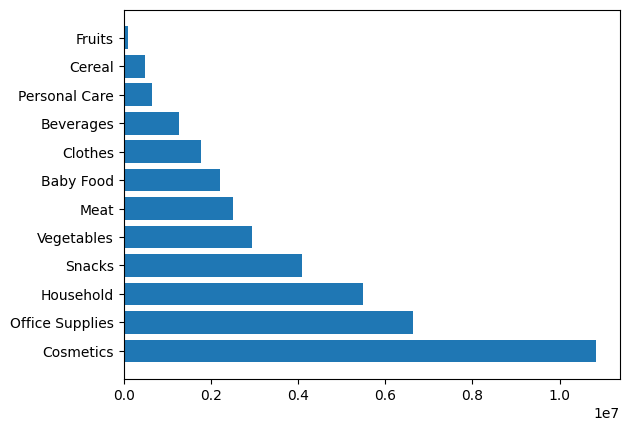

In [108]:
items_profit = countries_2017.groupby('Item Type')['Total Profit'].sum().sort_values(ascending=False).reset_index()
print(items_profit)

plt.barh(items_profit['Item Type'], items_profit['Total Profit'])

Netherlands


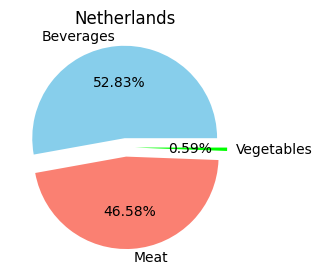




Russia
   Item Type  Total Profit
0  Household  1,240,986.24


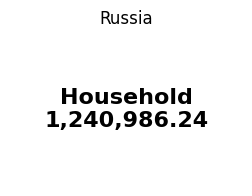




Poland
   Item Type  Total Profit
0  Household    149,985.65


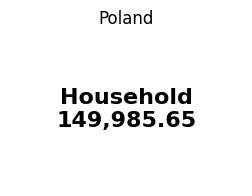




United Kingdom


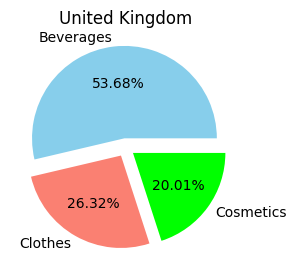




Bulgaria


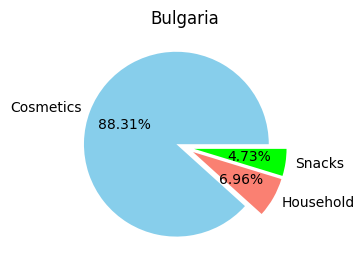




Switzerland


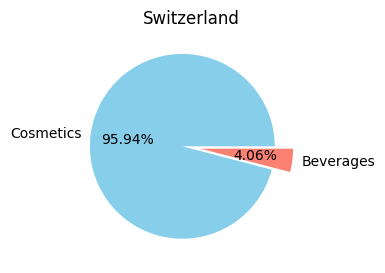




Latvia


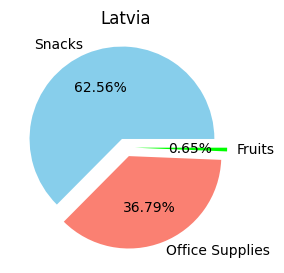




Germany


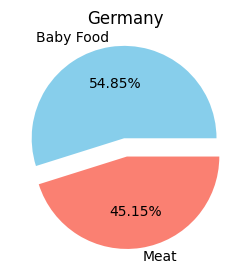




Sweden


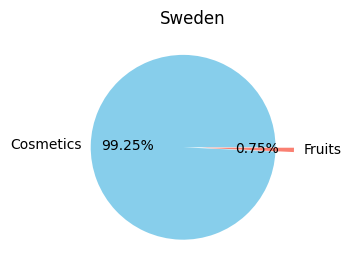




Norway
  Item Type  Total Profit
0      Meat    314,371.20


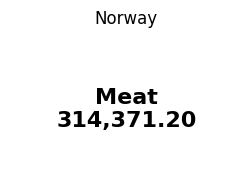




Estonia


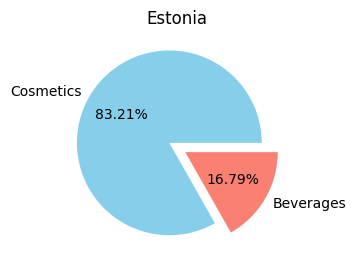




Belarus


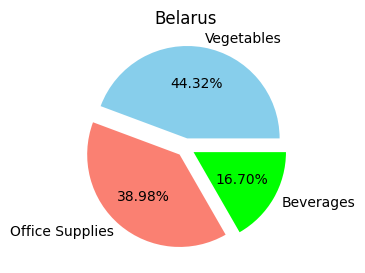




Austria


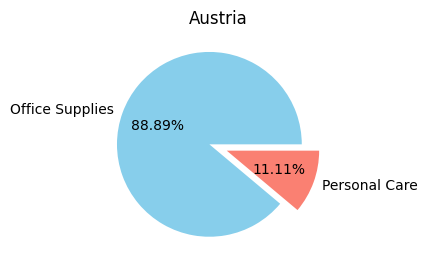




Monaco
  Item Type  Total Profit
0    Cereal    194,632.23


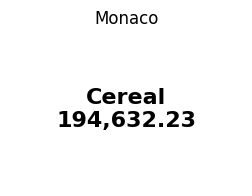




Ireland


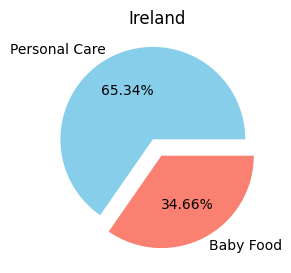




Croatia
   Item Type  Total Profit
0  Beverages    163,960.20


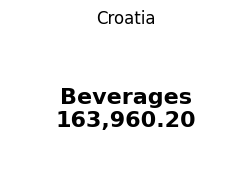




Greece


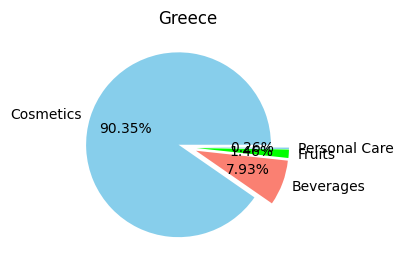




Albania
   Item Type  Total Profit
0  Household    289,861.77


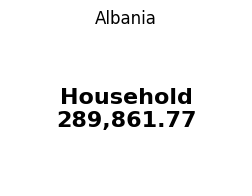




Spain


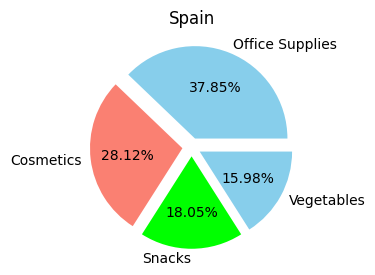




San Marino


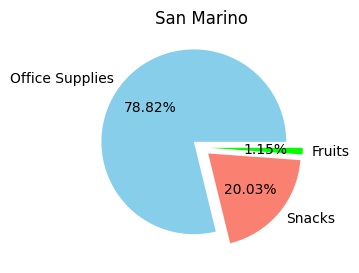




Ukraine


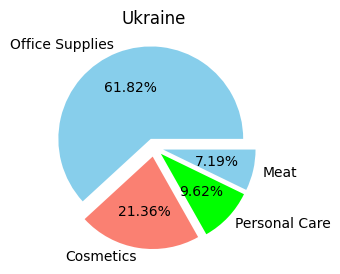




Georgia


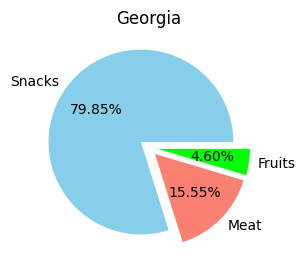




Serbia
         Item Type  Total Profit
0  Office Supplies  1,172,105.00


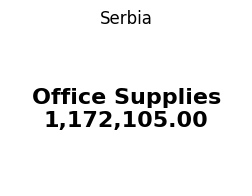




Andorra


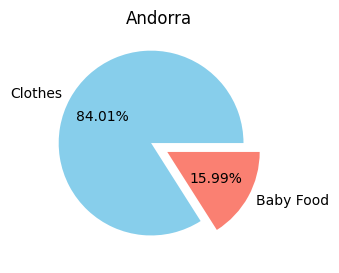




Czech Republic


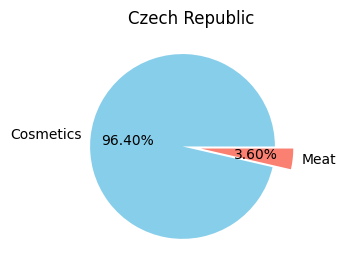




Lithuania
    Item Type  Total Profit
0  Vegetables    441,846.87


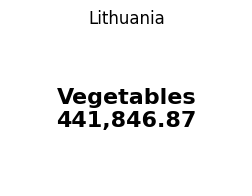




Romania


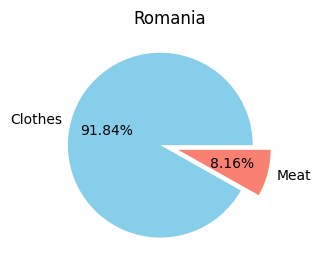




Macedonia


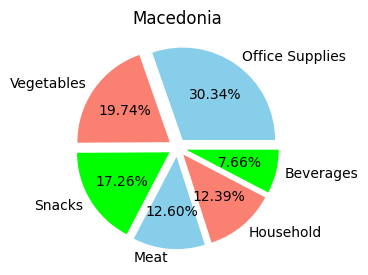




Kosovo


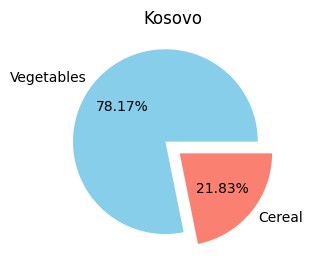




France


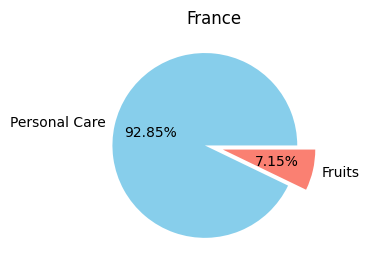




Montenegro


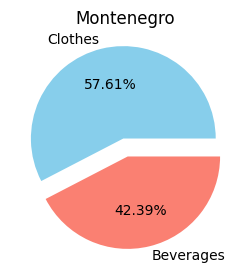




Slovenia


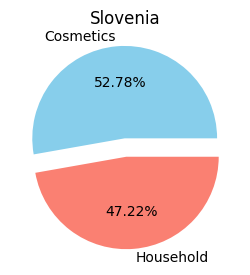




Iceland


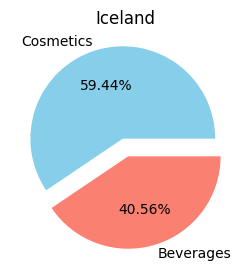




Luxembourg


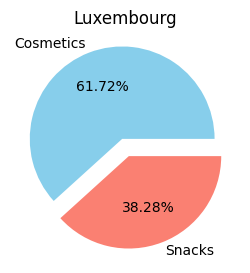




Italy
   Item Type  Total Profit
0  Baby Food    455,814.30


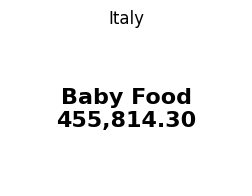




Finland


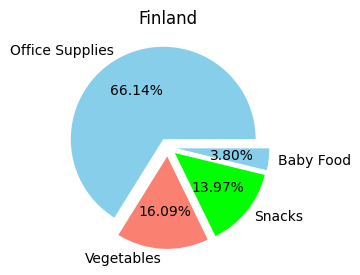




Slovakia
   Item Type  Total Profit
0  Beverages     10,539.18


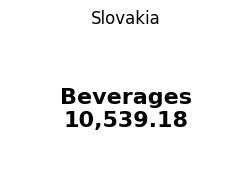




Cyprus
  Item Type  Total Profit
0      Meat    580,522.80


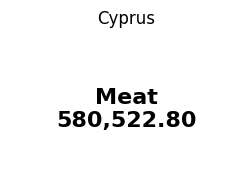




Moldova 
   Item Type  Total Profit
0  Baby Food    147,049.24


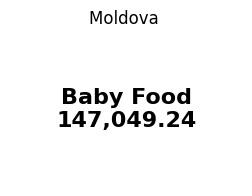




Vatican City


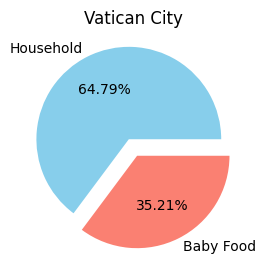




Belgium
    Item Type  Total Profit
0  Vegetables    148,292.37


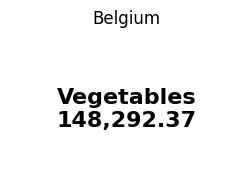




Armenia


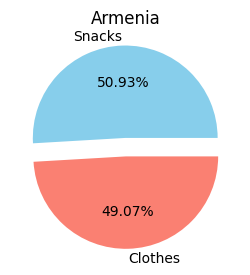




Liechtenstein


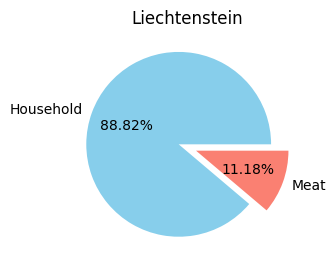




Hungary
  Item Type  Total Profit
0    Snacks    172,367.64


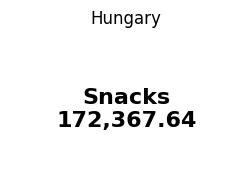




Malta
       Item Type  Total Profit
0  Personal Care    177,149.14


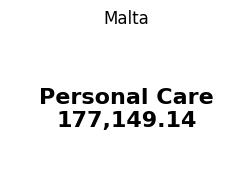

In [109]:
for i in countries_2017['Country'].unique().tolist():
    print(f'{i}')
    temp = countries_2017[countries_2017['Country'] == i].groupby('Item Type')['Total Profit'].sum().sort_values(ascending=False).reset_index()
    
    if(len(temp['Item Type'].tolist()) == 1):
        print(temp)
        plt.figure(figsize=(3,2))
        value = temp['Total Profit'].iloc[0]
        item = temp['Item Type'].iloc[0]

        plt.text(0.5, 0.5, f"{item}\n{value:,.2f}",
        ha='center', va='center',
        fontsize=16, fontweight='bold')
        plt.title(i)
        plt.axis("off")   # hide axes
        plt.show()
            
    else:
        plt.figure(figsize=(3,3))
        plt.pie(temp['Total Profit'],
                labels=temp['Item Type'],explode= [0.1] * len(temp['Item Type']),
                colors=['skyblue','salmon','lime'], autopct=('%.2f%%'))
        plt.title(i)
        plt.show()
    # print(temp)    
    print('\n\n')

Online / Offline performance

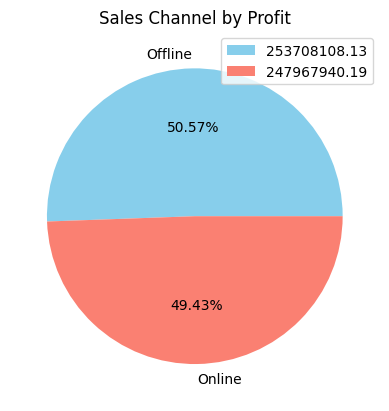

difference between sales channels profits: 
5740167.939999998 $


In [151]:
# df['Sales Channel'].head()
temp = df.groupby('Sales Channel')['Total Profit'].sum().reset_index()
plt.pie(temp['Total Profit'], autopct='%0.2f%%',
        labels=temp['Sales Channel'], colors=['skyblue', 'salmon'])
plt.title('Sales Channel by Profit')
plt.legend(temp['Total Profit'].round(2))
plt.show()
print('difference between sales channels profits: ')
print(abs(temp['Total Profit'][0]-temp['Total Profit'][1]), '$')

shipping delayes

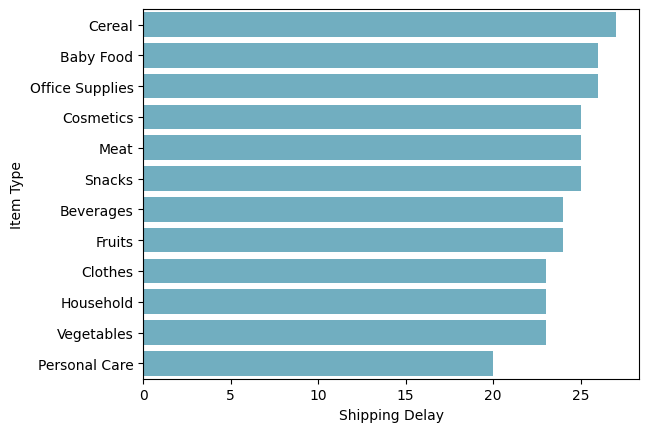

In [198]:
# df[['Order Date','Ship Date']].
df['Shipping Delay'] = df['Ship Date'] - df['Order Date']
# df[['Order Date','Ship Date','Shipping Delay']].head()
df['Shipping Delay'] = df['Shipping Delay'].dt.days
delayByItem = df.groupby('Item Type')['Shipping Delay'].mean().astype(int).sort_values(ascending=False).reset_index()
sns.barplot(data = delayByItem, x='Shipping Delay', y='Item Type',color=sns.color_palette('deep')[9])
plt.show()